In [1]:
import pandas as pd
import re
import numpy as np
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr
import matplotlib.cm as cm
from matplotlib.colors import to_hex

In [16]:
# Load data
vabb = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/01vabb_rnaagecalc-07272025.csv")
# Rename the first column to SampleID
vabb.rename(columns={vabb.columns[0]: "SampleID"}, inplace=True)
# Replace the letter between numbers with an underscore
vabb["SampleID"] = vabb["SampleID"].str.replace(r"(?<=\d)[A-Z]+(?=\d)", "_", regex=True)
# Load phenotype data
pheno_path = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00phenotype/00vabb/01PhenoMeta_assoc_08032025.csv"
pheno_data = pd.read_csv(pheno_path)
# Create suffixes
suffixes = ["_9", "_24", "_25", "_11"]
# Replicate and modify pheno_data
pheno_data_expanded = pd.concat([
    pheno_data.assign(SampleID="Sample" + pheno_data["SampleID"].astype(str) + suffix)
    for suffix in suffixes
], ignore_index=True)
# Merge on SampleID
merged_df = pd.merge(pheno_data_expanded, vabb, on="SampleID", how="inner")

In [17]:
# loading phenotype data
phenoPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00phenotype/01uthealth/00MetaData_UTHealth_RNAseq-07292025.csv"
phenoData = pd.read_csv(phenoPath)
phenoData.rename(columns={phenoData.columns[0]: "SampleID"}, inplace=True)
# Load data
uthh = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/00uthhealth_rnaagecalc-07272025.csv")
# Rename the first column to SampleID
uthh.rename(columns={uthh.columns[0]: "SampleID"}, inplace=True)
# Merge on SampleID
merged_df2 = pd.merge(phenoData, uthh, on="SampleID", how="inner")

In [18]:
# Load data
dpclo = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/00deepclock-08032025.csv")
# Rename and keep only SampleID and KPANN_brain columns
dpclo = dpclo.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'KPANN_brain']]
# Load KPANN clock trained in VABB for UTHealth
adicloc = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/01deepclock_UTHealth_only-08052025.csv")
adicloc = adicloc.rename(columns={'KPANNtrainedVABB_brain_clock': 'KPANNtrainedVABB_brain'})
# Merge with both filtered datasets
merged_df2_com = pd.merge(merged_df2, dpclo, on='SampleID')
merged_df2_com = pd.merge(merged_df2_com, adicloc, on='SampleID')
merged_df_com = pd.merge(merged_df, dpclo, on='SampleID')

In [30]:
# Add GSE from GEO cohort
# Load data
gse_kpann = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/04gsecohort_kpnaa_clock_prediction-08052025.txt", sep = '\t')
gse_kpann = gse_kpann.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'KPANN_brain']]
# Load rnaagecalc
gse_rnaage = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/04geocohorts-08032025/00gse102556-08052025.csv")
gse_rnaage = gse_rnaage.rename(columns={'sample': 'SampleID', 'age': 'Age'})
merged_df3_com = pd.merge(gse_kpann, gse_rnaage, on='SampleID')
merged_df3_com

,SampleID,KPANN_brain,DESeq2_adipose_tissue,Pearson_adipose_tissue,Dev_adipose_tissue,deMagalhaes_adipose_tissue,GenAge_adipose_tissue,GTExAge_adipose_tissue,Peters_adipose_tissue,all_adipose_tissue,...,GTExAge_vagina,Peters_vagina,all_vagina,geo_accession,Age,gender,rin,phenotype,cause_of_death,pmi
0,S32.BA11,21.985580,80.281937,54.384690,64.372344,39.073707,65.160396,29.396003,55.288970,55.753672,...,125.733815,63.801239,23.112180,GSM2740610,40,Male,5.8,CTRL,Suicide,29.75
1,S40.BA11,41.442410,95.788643,64.441648,69.336314,37.682381,76.002908,38.234114,55.548032,68.268121,...,134.143672,67.750014,32.619739,GSM2740611,49,Male,7.0,MDD,Suicide,32.00
2,S51.BA11,53.645161,88.514121,59.738752,64.121250,34.565318,82.295501,44.690326,68.098691,63.731931,...,140.294854,66.351854,39.767697,GSM2740614,53,Male,8.0,MDD,Suicide,33.50
3,S57.BA11,26.451389,104.202546,78.043584,65.080978,46.028843,73.195583,67.239018,71.401615,72.944882,...,130.192762,65.913155,35.297408,GSM2740616,55,Male,7.5,CTRL,Accident,24.00
4,S68.BA11,28.078577,80.773727,62.074566,65.198484,32.195023,61.911529,35.622196,42.238670,54.858321,...,131.872110,69.304578,24.622006,GSM2740620,28,Male,6.1,MDD,Suicide,36.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,S113.BA11,59.824749,88.167120,59.144018,68.144915,40.796413,72.460785,43.176042,63.890393,63.939338,...,130.976850,65.602820,34.921526,GSM2740632,63,Male,6.5,MDD,Suicide,50.00
92,S212.BA11,18.689510,94.698982,64.601116,62.311375,37.967219,70.312840,47.060979,65.209796,68.198891,...,135.869207,70.795801,26.043928,GSM2740648,82,Female,8.0,CTRL,Natural,106.00
93,S69.BA8_9,52.756557,84.167865,50.618863,63.099601,37.491272,71.770834,41.283783,68.727427,62.882131,...,132.899624,66.182109,38.800367,GSM2740673,46,Female,7.5,MDD,Suicide,15.00
94,S23.BA8_9,4.930076,82.844717,48.492016,63.524496,33.213625,70.078951,45.077475,68.374492,62.107588,...,131.393051,68.111361,32.521667,GSM2740660,19,Male,7.7,CTRL,Suicide,27.75


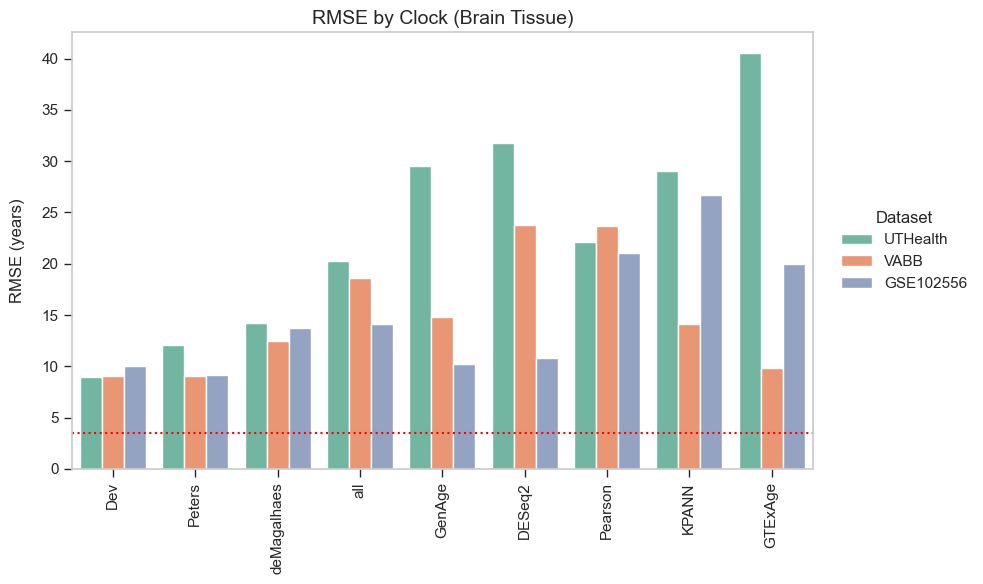

In [32]:
# --- 1. Subset relevant columns from both datasets ---
# Defining a function to extract the columns with brains and Age
def extract_age_and_brain(df, source_label):
    # Use 'AgeDeath' if available, otherwise fallback to 'Age'
    age_col = 'AgeDeath' if 'AgeDeath' in df.columns else 'Age'
    # Get columns that end with '_brain'
    brain_cols = [col for col in df.columns if col.endswith('_brain')]
    # Extract relevant columns
    subset = df[[age_col] + brain_cols].copy()
    # Rename age column to a common name
    subset.rename(columns={age_col: 'Age'}, inplace=True)
    # Drop rows with any NA values
    subset = subset.dropna()
    # Add source column
    subset['Source'] = source_label
    return subset

# Create subsets
gse_subset = extract_age_and_brain(merged_df3_com, 'GSE102556')
uth_subset = extract_age_and_brain(merged_df2_com, 'UTHealth')
vabb_subset = extract_age_and_brain(merged_df_com, 'VABB')

# Remove KPANNtrainedVABB_brain column from both subsets if it exists
columns_to_remove = ['KPANNtrainedVABB_brain']
uth_subset = uth_subset.drop(columns=columns_to_remove, errors='ignore')
vabb_subset = vabb_subset.drop(columns=columns_to_remove, errors='ignore')
gse_subset = gse_subset.drop(columns=columns_to_remove, errors='ignore')

# --- 2. Combine both datasets by row ---
combined_df = pd.concat([uth_subset, vabb_subset, gse_subset], ignore_index=True)

# --- 3. Compute RMSE and correlation per clock per dataset ---
results = []

age_col = 'AgeDeath'
clock_cols = [col for col in combined_df.columns if col.endswith('_brain')]

for source in combined_df['Source'].unique():
    sub_df = combined_df[combined_df['Source'] == source]
    if 'Age' not in sub_df.columns:
        raise ValueError(f"'Age' column not found in source {source}")
    y_true = sub_df['Age']
        
    for col in clock_cols:
        if col in sub_df.columns:
            y_pred = sub_df[col]
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            corr = y_true.corr(y_pred)
            results.append({
                'Clock': col,
                'ClockType': col.replace('_brain', ''),
                'Tissue': 'brain',
                'RMSE': rmse,
                'Correlation': corr,
                'Source': source
            })

results_df = pd.DataFrame(results)

# --- 4. Plot RMSE by Clock, colored by dataset (Barplot version) ---
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Sort clocks by mean RMSE
mean_rmse_order = results_df.groupby('ClockType')['RMSE'].mean().sort_values().index
# Create barplot
ax = sns.barplot(
    data=results_df,
    x='ClockType',
    y='RMSE',
    hue='Source',
    palette='Set2',
    order=mean_rmse_order,
    errorbar='se'
)

# Titles and labels
plt.title("RMSE by Clock (Brain Tissue)", fontsize=14)
plt.xlabel("")
plt.ylabel("RMSE (years)", labelpad=12)  # Add padding here
plt.xticks(rotation=90)

# Remove horizontal grid lines
ax.grid(False, axis='y')

# Move legend outside, remove frame
legend = plt.legend(
    title='Dataset',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False  # Removes gray square
)

# Add red dotted horizontal line at y=8.5
ax.axhline(3.5, color='red', linestyle='dotted', linewidth=1.5)

# Ensure tick lines are visible
ax.tick_params(axis='x', which='both', bottom=True, top=False, length=6, width=1)
ax.tick_params(axis='y', which='both', left=True, right=False, length=6, width=1)

plt.tight_layout()
plt.show()

In [33]:
# Load Epigenetic clocks
# Load the .rds file
result = pd.read_csv('C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/03epigenclocks-08022025/01pheno_uthealth_epiclocks-08042025.txt', sep='\t')  # Replace with your file path
df = result
# Identify overlapping columns except the merge key 'SAB'
overlap_cols = [col for col in df.columns if col in merged_df2_com.columns and col != 'SAB']
# Drop those overlapping columns from df
df_filtered = df.drop(columns=overlap_cols)
# Merge on 'SAB'
merged_df2_com_epi = pd.merge(merged_df2_com, df_filtered, on='SAB')
merged_df2_com_epi

,SampleID,SAB,UTID,Ethnicity,Gender,Age,PMIhrs,RIN_novogene,pH,Cause_of_Death,...,epiTOC2,StochClock1,StochClock2,StochClock3,EAA_StochClock1,EAA_StochClock2,EAA_StochClock3,CausAge,DamAge,AdaptAge
0,A67900,67900,UTHBC0001,White,Male,17,22.433333,6.9,6.41,splenic_artery_aneurysm,...,1171.382313,4.137158,-11.857335,38.834845,-10.791022,-0.836560,-3.168832,52.776132,84.475625,-4.265311
1,A67905,67905,UTHBC0006,White,Male,43,21.316667,8.4,6.83,Cardiovascular disease,...,1500.681135,22.900741,9.618219,45.709501,-1.737740,4.720552,1.928727,66.515959,87.605638,10.192004
2,A67906,67906,UTHBC0007,White,Male,44,22.250000,7.5,6.46,DVT/PE,...,988.845902,19.478930,5.036796,41.521593,-5.533025,-0.473119,-2.327530,60.466816,81.439013,-2.802180
3,A67910,67910,UTHBC0011,White,Male,59,27.216667,7.7,6.59,Cardiovascular disease,...,473.296379,33.751962,23.609749,50.462931,3.137911,8.916117,5.588559,68.650683,104.547380,-6.322340
4,A67911,67911,UTHBC0012,White,Male,42,19.100000,7.5,6.75,amphetamine induced aortic dissection,...,207.140408,26.696247,6.059177,43.276495,2.431239,1.773758,-0.435929,66.263361,85.091492,-10.833851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,A67994,67994,UTHBC0095,Hispanic,Male,59,32.350000,6.5,6.80,Cardiovascular disease,...,-11.011478,36.605480,13.243695,43.163043,5.991429,-1.449937,-1.711329,66.907035,89.736998,-11.448714
69,A67995,67995,UTHBC0096,White,Male,63,25.333333,6.5,6.70,Cardiovascular disease,...,143.549788,33.514544,18.314629,45.672731,1.406600,1.172006,0.524960,65.820538,102.425376,-17.520189
70,A67996,67996,UTHBC0097,White,Female,36,24.466667,7.2,6.58,toxic effects of hydrocodone and morphine,...,400.255764,13.437168,-8.717783,45.658570,-8.587002,-9.329716,2.356245,59.656337,93.495941,-40.955033
71,A67997,67997,UTHBC0098,Hispanic,Male,61,26.383333,7.2,6.89,Cardiovascular disease,...,59.736717,24.666723,26.599342,47.605941,-6.694275,10.681215,2.594869,63.927683,101.410378,-22.989839


In [34]:
# Load cortical clock
rds_path = ('C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/03epigenclocks-08022025/00uthealth_brain-08032025.rds')  # Replace with your file path
result = pyreadr.read_r(rds_path)
# Extract the DataFrame (it's usually the first item in the returned dictionary)
df2 = list(result.values())[0]
df2 = df2[['SAB', 'corticalClock', 'Zhang2019']]
# Merge on 'SAB'
merged_df2_com_epi = pd.merge(merged_df2_com_epi, df2, on='SAB')
# Rename specific clock columns
merged_df2_com_epi.rename(columns={
    'StochClock1': 'StocH',
    'StochClock2': 'StocP',
    'StochClock3': 'StocZ',
    'EAA_StochClock1': 'EAAStocH',
    'EAA_StochClock2': 'EAAStocP',
    'EAA_StochClock3': 'EAAStocZ',
}, inplace=True)
merged_df2_com_epi

,SampleID,SAB,UTID,Ethnicity,Gender,Age,PMIhrs,RIN_novogene,pH,Cause_of_Death,...,StocP,StocZ,EAAStocH,EAAStocP,EAAStocZ,CausAge,DamAge,AdaptAge,corticalClock,Zhang2019
0,A67900,67900,UTHBC0001,White,Male,17,22.433333,6.9,6.41,splenic_artery_aneurysm,...,-11.857335,38.834845,-10.791022,-0.836560,-3.168832,52.776132,84.475625,-4.265311,14.708891,12.244185
1,A67905,67905,UTHBC0006,White,Male,43,21.316667,8.4,6.83,Cardiovascular disease,...,9.618219,45.709501,-1.737740,4.720552,1.928727,66.515959,87.605638,10.192004,45.442636,29.310722
2,A67906,67906,UTHBC0007,White,Male,44,22.250000,7.5,6.46,DVT/PE,...,5.036796,41.521593,-5.533025,-0.473119,-2.327530,60.466816,81.439013,-2.802180,41.915612,38.357728
3,A67910,67910,UTHBC0011,White,Male,59,27.216667,7.7,6.59,Cardiovascular disease,...,23.609749,50.462931,3.137911,8.916117,5.588559,68.650683,104.547380,-6.322340,57.714957,44.722716
4,A67911,67911,UTHBC0012,White,Male,42,19.100000,7.5,6.75,amphetamine induced aortic dissection,...,6.059177,43.276495,2.431239,1.773758,-0.435929,66.263361,85.091492,-10.833851,43.888331,31.154606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,A67994,67994,UTHBC0095,Hispanic,Male,59,32.350000,6.5,6.80,Cardiovascular disease,...,13.243695,43.163043,5.991429,-1.449937,-1.711329,66.907035,89.736998,-11.448714,56.434553,44.812303
69,A67995,67995,UTHBC0096,White,Male,63,25.333333,6.5,6.70,Cardiovascular disease,...,18.314629,45.672731,1.406600,1.172006,0.524960,65.820538,102.425376,-17.520189,59.972525,44.630765
70,A67996,67996,UTHBC0097,White,Female,36,24.466667,7.2,6.58,toxic effects of hydrocodone and morphine,...,-8.717783,45.658570,-8.587002,-9.329716,2.356245,59.656337,93.495941,-40.955033,40.245391,20.486884
71,A67997,67997,UTHBC0098,Hispanic,Male,61,26.383333,7.2,6.89,Cardiovascular disease,...,26.599342,47.605941,-6.694275,10.681215,2.594869,63.927683,101.410378,-22.989839,57.962253,42.146032


C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_31336\3012454325.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


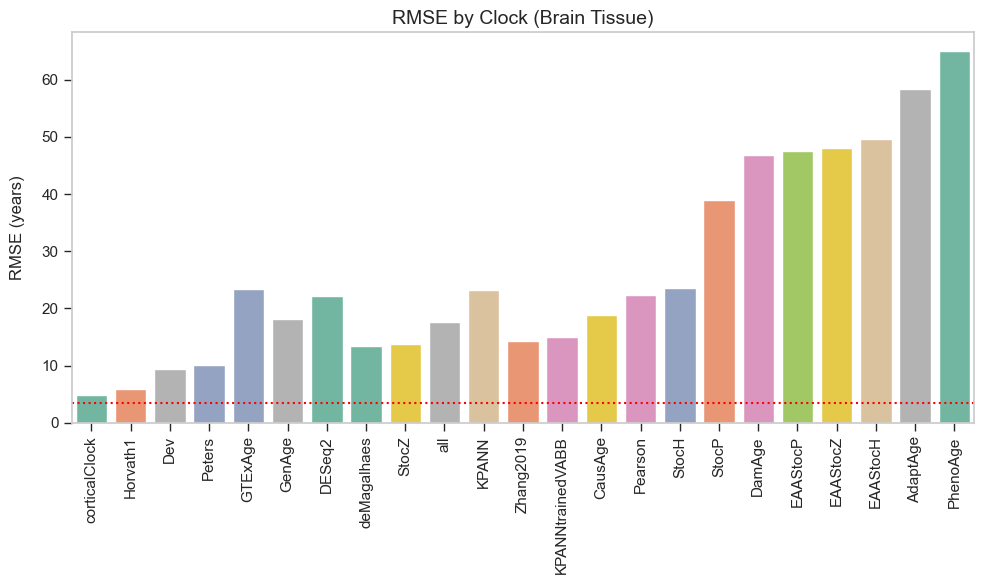

In [35]:
# Clocks of interest
# Define all clocks of interest
clock_cols = ['KPANNtrainedVABB_brain', 'Zhang2019', 'Horvath1', 'PhenoAge', 'StocH', 'StocP', 'StocZ', 'EAAStocH', 'EAAStocP', 'EAAStocZ', 'corticalClock', 'CausAge', 'AdaptAge', 'DamAge']
age_col = 'Age'

for clock in clock_cols:
    subset = merged_df2_com_epi.dropna(subset=[clock])
    rmse = root_mean_squared_error(subset['Age'], subset[clock])
    corr, _ = pearsonr(subset['Age'], subset[clock])
    results.append({
        'ClockType': clock.replace('_brain', ''),
        'RMSE': rmse,
        'Correlation': corr
    })

results_df = pd.DataFrame(results)

# Plot RMSE by Clock (Barplot version)
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Sort clocks by mean RMSE
mean_rmse_order = results_df.sort_values(by='RMSE')['ClockType']

# Create barplot
ax = sns.barplot(
    data=results_df,
    x='ClockType',
    y='RMSE',
    palette='Set2',
    order=mean_rmse_order,
    errorbar=None  # No grouping, so no error bar
)

# Titles and labels
plt.title("RMSE by Clock (Brain Tissue)", fontsize=14)
plt.xlabel("")
plt.ylabel("RMSE (years)", labelpad=12)
plt.xticks(rotation=90)

# Remove horizontal grid lines
ax.grid(False, axis='y')

# Remove legend (no grouping by dataset)
ax.get_legend().remove() if ax.get_legend() else None

# Add red dotted horizontal line at y=8.5
ax.axhline(3.5, color='red', linestyle='dotted', linewidth=1.5)

# Make tick marks visible
ax.tick_params(axis='x', which='both', bottom=True, top=False, length=6, width=1)
ax.tick_params(axis='y', which='both', left=True, right=False, length=6, width=1)

plt.tight_layout()
plt.show()

In [ ]:
# Define epigenetic clocks
epi_clock_cols = ['Zhang2019', 'Horvath1', 'PhenoAge', 'StocH', 'StocP', 'StocZ', 'EAAStocH', 'EAAStocP', 'EAAStocZ', 'corticalClock', 'CausAge', 'AdaptAge', 'DamAge']

# Transcriptomic clocks
brain_cols = [col for col in merged_df2_com_epi.columns if col.endswith('_brain')]

# Merge relevant columns
required_cols = ['SAB', 'Age'] + epi_clock_cols
merged = pd.merge(merged_df2_com_epi[required_cols], merged_df2_com_epi[['SAB'] + brain_cols], on='SAB')

# Colors
colors = sns.color_palette("tab10", n_colors=len(brain_cols))

# One plot per epigenetic clock
for clock in epi_clock_cols:
    plt.figure(figsize=(8, 6))
    sns.set(style="white")  # Clean background with no grid

    ax = plt.gca()  # Get current axes object

    # Plot regression lines per brain clock
    for i, brain_col in enumerate(brain_cols):
        temp = merged[[clock, brain_col]].dropna()
        sns.regplot(
            x=temp[clock],
            y=temp[brain_col],
            scatter=False,
            label=brain_col.replace('_brain', ''),
            color=colors[i],
            line_kws={"linewidth": 2, "linestyle": "--"},
            ax=ax  # use the same axes object
        )

    # Add red dashed line for chronological age
    temp_age = merged[[clock, 'Age']].dropna()
    sns.regplot(
        x=temp_age[clock],
        y=temp_age['Age'],
        scatter=False,
        color='red',
        label='Chronological Age',
        line_kws={"linewidth": 2, "linestyle": ":"},
        ax=ax
    )

    # Ensure tick marks are visible and styled
    ax.tick_params(axis='x', which='both', bottom=True, top=False, length=6, width=1)
    ax.tick_params(axis='y', which='both', left=True, right=False, length=6, width=1)

    # Titles and labels
    ax.set_title(f'{clock} vs Transcriptomic Clocks (Brain)', fontsize=14)
    ax.set_xlabel(clock, fontsize=12)
    ax.set_ylabel('Transcriptomic Clock / Age', fontsize=12)
    ax.legend(title='Comparison', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

    plt.tight_layout()
    plt.show()

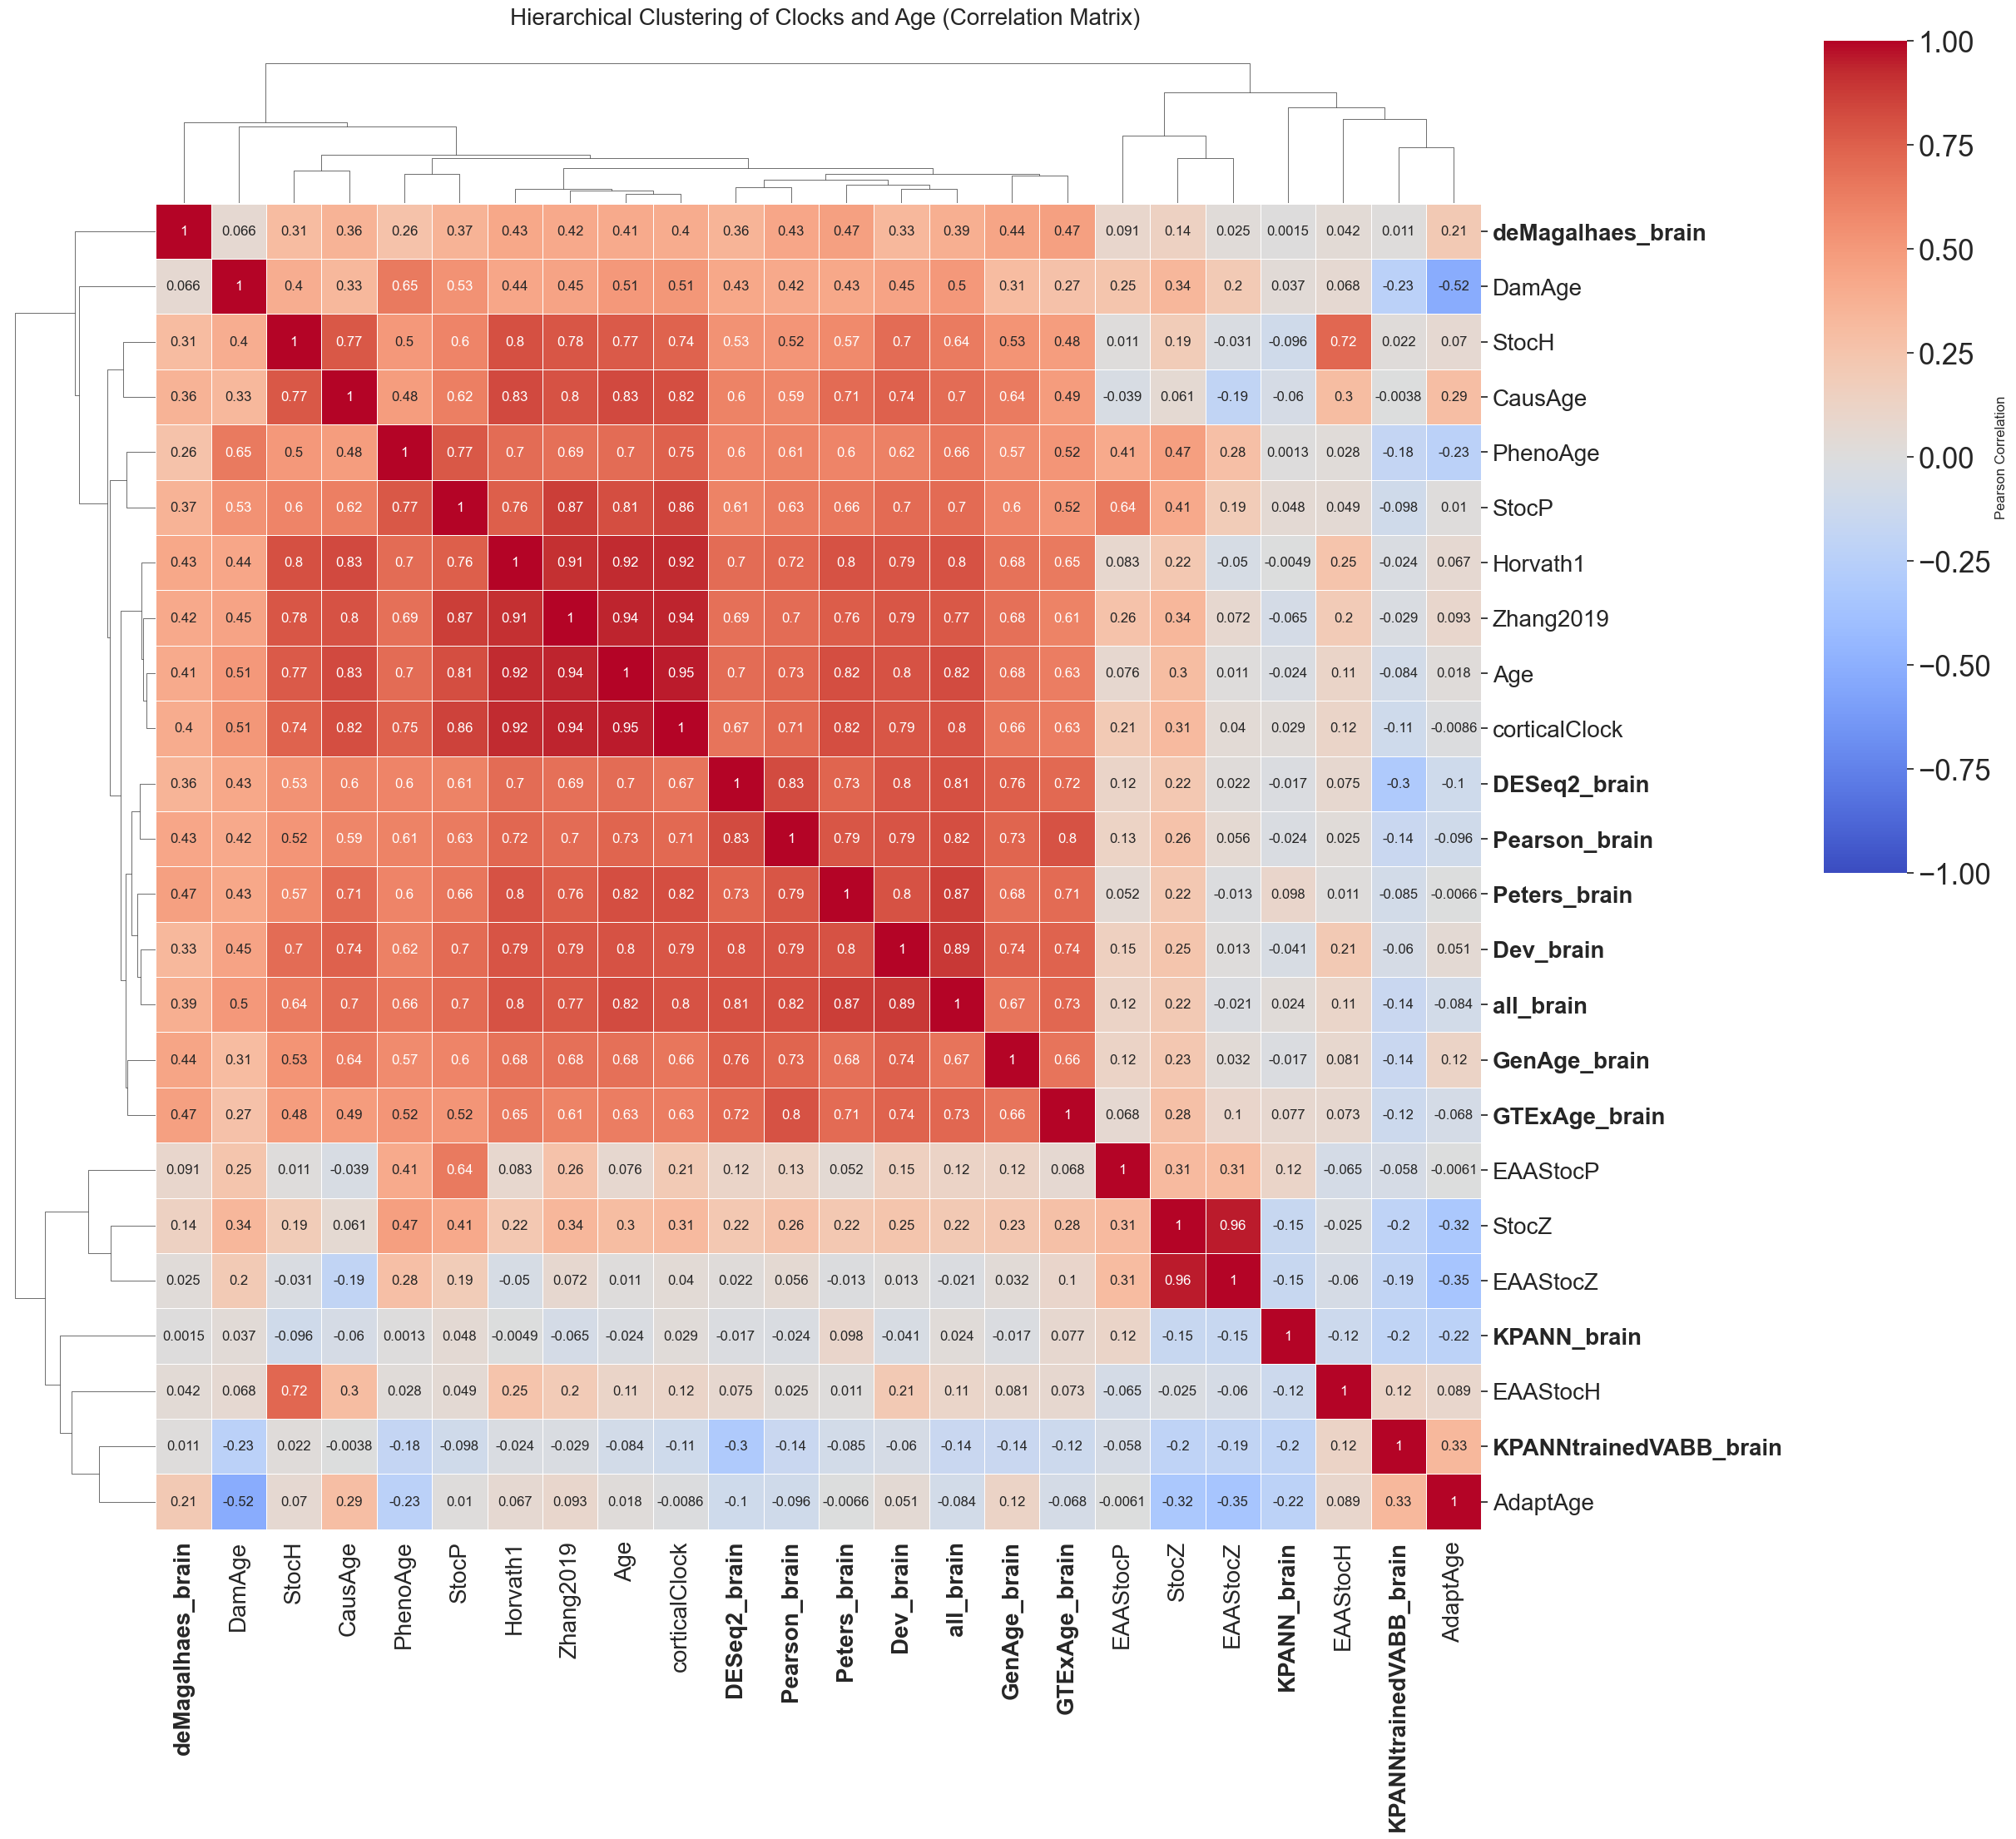

In [43]:
# Define clocks and columns
brain_cols = [col for col in merged_df2_com_epi.columns if col.endswith('_brain')]
required_cols = ['SAB', 'Age'] + clock_cols + brain_cols

# Subset and drop missing values
corr_df = merged_df2_com_epi[required_cols].dropna()
corr_df = corr_df.loc[:, ~corr_df.columns.duplicated()]

# Compute correlation matrix
corr_matrix = corr_df.drop(columns='SAB').corr(method='pearson')

# Plot clustermap
sns.set(style="white")
cg = sns.clustermap(
    corr_matrix,
    method='average',
    metric='euclidean',
    cmap='coolwarm',
    annot=True,
    linewidths=0.5,
    figsize=(20, 20),
    cbar_pos=(1.1, 0.5, 0.05, 0.5),
    cbar_kws={'label': 'Pearson Correlation'},
    dendrogram_ratio=(.1, .1),
    xticklabels=True,
    yticklabels=True,
    vmin=-1,
    vmax=1
)

# Customize tick labels — bold if ends with '_brain'
# For x-axis
new_labels_x = []
for label in cg.ax_heatmap.get_xticklabels():
    text = label.get_text()
    label.set_fontweight('bold' if text.endswith('_brain') else 'normal')
    label.set_rotation(90)  # rotate for readability
    label.set_fontsize(20)  # increase font size
    new_labels_x.append(label)
cg.ax_heatmap.set_xticklabels(new_labels_x)

# For y-axis
new_labels_y = []
for label in cg.ax_heatmap.get_yticklabels():
    text = label.get_text()
    label.set_fontweight('bold' if text.endswith('_brain') else 'normal')
    label.set_rotation(0)
    label.set_fontsize(20)  # increase font size
    new_labels_y.append(label)
cg.ax_heatmap.set_yticklabels(new_labels_y)
cg.cax.tick_params(labelsize=25)
# Title
plt.suptitle("Hierarchical Clustering of Clocks and Age (Correlation Matrix)", fontsize=20, y=1.02)
plt.show()